# Azeem Ahmad Khan
# Deep learning assignment 2
# 21i-1720

In [1]:
!nvidia-smi

import os, glob, random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

Mon Nov 10 17:31:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Download Kaggle Dataset (bahushruth/legalclausedataset)

try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

path = kagglehub.dataset_download("bahushruth/legalclausedataset")
print("Dataset path:", path)
print("Files:", os.listdir(path))
DATA_DIR = path


Using Colab cache for faster access to the 'legalclausedataset' dataset.
Dataset path: /kaggle/input/legalclausedataset
Files: ['certain-definitions.csv', 'proprietary_rights.csv', 'limitation-of-liability.csv', 'severability-of-provisions.csv', 'other-agreements.csv', 'representations.csv', 'payment-terms.csv', 'definitions.csv', 'effectiveness.csv', 'additional-documents.csv', 'no-assignment.csv', 'benefits.csv', 'vesting.csv', 'construction.csv', 'time-of-the-essence.csv', 'entire-agreement.csv', 'execution.csv', 'material-contracts.csv', 'cooperation.csv', 'compliance.csv', 'transfer.csv', 'security.csv', 'holidays.csv', 'severance.csv', 'limited_liability.csv', 'witnesseth-that.csv', 'release.csv', 'parties-in-interest.csv', 'arbitration.csv', 'title-to-assets.csv', 'bank-accounts.csv', 'purchase-price.csv', 'standard-terms-and-conditions-of-trust.csv', 'indebtedness.csv', 'notice-of-termination.csv', 'duration-and-termination.csv', 'preamble.csv', 'financial-statements.csv', 'def

In [6]:
#Load & Standardize All CSVs

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("CSV files found:", len(csv_files), csv_files)

def load_and_standardize(fp):
    df = pd.read_csv(fp)
    df.columns = [c.strip().lower() for c in df.columns]

    # Detect text column
    text_col = next(
        (c for c in ['clause_text', 'clause', 'text', 'sentence'] if c in df.columns),
        None
    )
    # Detect label column
    label_col = next(
        (c for c in ['clause_type', 'type', 'label', 'category', 'class'] if c in df.columns),
        None
    )

    if text_col is None:
        raise ValueError(f"No text column found in {fp}, columns={df.columns.tolist()}")

    if label_col is None:
        # Fallback: use filename as type if no label column
        df['clause_type'] = os.path.basename(fp).replace(".csv", "")
        label_col = 'clause_type'

    df = df[[text_col, label_col]].rename(
        columns={text_col: 'clause_text', label_col: 'clause_type'}
    )
    df['source_file'] = os.path.basename(fp)
    return df

dfs = [load_and_standardize(fp) for fp in csv_files]
data = pd.concat(dfs, ignore_index=True)
data = data.dropna(subset=['clause_text', 'clause_type'])
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Total clauses:", len(data))
print("Unique clause types:", data['clause_type'].nunique())
print(data[['clause_text', 'clause_type']].head())

CSV files found: 395 ['/kaggle/input/legalclausedataset/certain-definitions.csv', '/kaggle/input/legalclausedataset/proprietary_rights.csv', '/kaggle/input/legalclausedataset/limitation-of-liability.csv', '/kaggle/input/legalclausedataset/severability-of-provisions.csv', '/kaggle/input/legalclausedataset/other-agreements.csv', '/kaggle/input/legalclausedataset/representations.csv', '/kaggle/input/legalclausedataset/payment-terms.csv', '/kaggle/input/legalclausedataset/definitions.csv', '/kaggle/input/legalclausedataset/effectiveness.csv', '/kaggle/input/legalclausedataset/additional-documents.csv', '/kaggle/input/legalclausedataset/no-assignment.csv', '/kaggle/input/legalclausedataset/benefits.csv', '/kaggle/input/legalclausedataset/vesting.csv', '/kaggle/input/legalclausedataset/construction.csv', '/kaggle/input/legalclausedataset/time-of-the-essence.csv', '/kaggle/input/legalclausedataset/entire-agreement.csv', '/kaggle/input/legalclausedataset/execution.csv', '/kaggle/input/legalcla

In [7]:
#Create Pairwise Dataset (Full Coverage, No O(n^2))

def create_pair_dataset_full_coverage(df, neg_multiplier=1):
    """
    Build a pairwise dataset:
    - Positive pairs: clauses of same type (covers all clauses).
    - Negative pairs: clauses of different types.
    Avoids exhaustive O(n^2) combinations.
    """
    df = df.dropna(subset=['clause_text', 'clause_type'])
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    by_type = {t: g['clause_text'].tolist() for t, g in df.groupby('clause_type')}
    types_list = list(by_type.keys())

    pairs = []
    labels = []

    # ---- Positive pairs (ensure each clause used at least once where possible)
    for t, clauses in by_type.items():
        n = len(clauses)
        if n < 2:
            continue

        idx = np.arange(n)
        np.random.shuffle(idx)

        # Pair consecutive clauses
        for i in range(0, n - 1, 2):
            c1 = clauses[idx[i]]
            c2 = clauses[idx[i + 1]]
            pairs.append((c1, c2))
            labels.append(1)

        # If odd number of clauses, pair last with a random previous
        if n % 2 == 1 and n > 1:
            last = clauses[idx[-1]]
            other = clauses[idx[random.randint(0, n - 2)]]
            pairs.append((last, other))
            labels.append(1)

    total_pos = sum(1 for l in labels if l == 1)
    print("Positive pairs:", total_pos)

    # ---- Negative pairs (different types)
    all_clauses = df[['clause_text', 'clause_type']].values.tolist()
    target_neg = total_pos * neg_multiplier

    neg_count = 0
    while neg_count < target_neg:
        c1_text, c1_type = random.choice(all_clauses)
        c2_text, c2_type = random.choice(all_clauses)
        if c1_type != c2_type:
            pairs.append((c1_text, c2_text))
            labels.append(0)
            neg_count += 1

    pair_df = pd.DataFrame(
        {'clause1': [p[0] for p in pairs],
         'clause2': [p[1] for p in pairs],
         'label': labels}
    )

    pair_df = pair_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return pair_df

pair_df = create_pair_dataset_full_coverage(data, neg_multiplier=1)
print("Total pairs:", len(pair_df))
print(pair_df['label'].value_counts())
pair_df.head()

Positive pairs: 75443
Total pairs: 150886
label
1    75443
0    75443
Name: count, dtype: int64


,clause1,clause2,label
0,ERISA. (a) Borrower shall not maintain or cont...,"ERISA. With respect to each Plan, each Credit ...",1
1,Grant of Option. Tracker has granted to the Pa...,"Grant of Option. Ben & Jerry's Homemade, Inc.,...",1
2,Counterparts. This Agreement may be signed in ...,Additional Documents. Landlord and Tenant agre...,0
3,Officer’s Certificate. On the Initial Borrowin...,Set-Off. In addition to any rights now or here...,0
4,"W I T N E S S E T H WHEREAS. Borrower, Lende...",Redemption. (a) The Board of Directors of the ...,0


In [8]:
#Train / Val / Test Split

train_df, temp_df = train_test_split(
    pair_df,
    test_size=0.2,
    stratify=pair_df['label'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print("Train label distribution:\n", train_df['label'].value_counts(normalize=True))


Train size: 120708
Val size: 15089
Test size: 15089
Train label distribution:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
#  Text Cleaning, Tokenization, Encoding

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text(t: str) -> str:
    t = str(t).lower()
    t = re.sub(r'\s+', ' ', t)
    return t.strip()

for df_ in (train_df, val_df, test_df):
    for col in ['clause1', 'clause2']:
        df_[col] = df_[col].apply(clean_text)

MAX_VOCAB = 30000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(
    pd.concat([train_df['clause1'], train_df['clause2']])
)

def encode_pairs(df):
    s1 = tokenizer.texts_to_sequences(df['clause1'])
    s2 = tokenizer.texts_to_sequences(df['clause2'])
    X1 = pad_sequences(s1, maxlen=MAX_LEN, padding='post', truncating='post')
    X2 = pad_sequences(s2, maxlen=MAX_LEN, padding='post', truncating='post')
    y = df['label'].astype('int32').values
    return X1, X2, y

X1_train, X2_train, y_train = encode_pairs(train_df)
X1_val, X2_val, y_val = encode_pairs(val_df)
X1_test, X2_test, y_test = encode_pairs(test_df)

print("X1_train:", X1_train.shape, "X2_train:", X2_train.shape, "y_train:", y_train.shape)

X1_train: (120708, 100) X2_train: (120708, 100) y_train: (120708,)


In [10]:
# Evaluation, History Plots, Save Curves

def evaluate_model(model, X1, X2, y_true, name="Model"):
    preds = model.predict([X1, X2], verbose=0).ravel()
    y_pred = (preds >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, preds)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    return {
        "model": name,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "auc": auc
    }

def plot_history(history, title="Model"):
    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend(); plt.grid(True)
    plt.show()

    # Accuracy
    if 'accuracy' in history.history:
        plt.figure()
        plt.plot(history.history['accuracy'], label='train_acc')
        plt.plot(history.history['val_accuracy'], label='val_acc')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy')
        plt.title(f'{title} - Accuracy')
        plt.legend(); plt.grid(True)
        plt.show()

def save_training_curves(history, model_name):
    """Save loss and accuracy curves as PNG files for the report."""
    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend(); plt.grid(True)
    fname = f"{model_name.replace(' ', '_')}_loss.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()

    # Accuracy
    if 'accuracy' in history.history:
        plt.figure()
        plt.plot(history.history['accuracy'], label='train_acc')
        plt.plot(history.history['val_accuracy'], label='val_acc')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy')
        plt.title(f'{model_name} - Accuracy')
        plt.legend(); plt.grid(True)
        fname = f"{model_name.replace(' ', '_')}_accuracy.png"
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.close()

    print(f"Saved training curves for {model_name}")

In [12]:
# Model 1 – Siamese BiLSTM

EMB_DIM = 128
LSTM_UNITS = 128

def build_bilstm_encoder(name="bilstm_encoder"):
    inp = Input(shape=(MAX_LEN,), name=f"{name}_input")
    x = layers.Embedding(MAX_VOCAB, EMB_DIM, mask_zero=True, name=f"{name}_emb")(inp)
    x = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True),
        name=f"{name}_bilstm"
    )(x)
    x = layers.GlobalMaxPooling1D(name=f"{name}_pool")(x)
    x = layers.Dense(128, activation='relu', name=f"{name}_dense")(x)
    x = layers.Dropout(0.2, name=f"{name}_dropout")(x)
    return models.Model(inp, x, name=name)

def build_siamese_bilstm():
    encoder = build_bilstm_encoder()

    inp1 = Input(shape=(MAX_LEN,), name="clause1_input")
    inp2 = Input(shape=(MAX_LEN,), name="clause2_input")

    enc1 = encoder(inp1)
    enc2 = encoder(inp2)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]), name="abs_diff")([enc1, enc2])
    mult = layers.Multiply(name="elementwise_mult")([enc1, enc2])
    concat = layers.Concatenate(name="concat")([enc1, enc2, diff, mult])

    x = layers.Dense(128, activation='relu', name="top_dense")(concat)
    x = layers.Dropout(0.3, name="top_dropout")(x)
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    model = models.Model(inputs=[inp1, inp2], outputs=out, name="Siamese_BiLSTM")
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-3),
        metrics=['accuracy']
    )
    return model

model_b1 = build_siamese_bilstm()
model_b1.summary()

Model: "Siamese_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ clause1_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clause2_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 128)       │  4,136,064 │ clause1_input[0]… │
│ (Functional)        │                   │            │ clause2_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_diff (Lambda)   │ (None, 128)       │          0 │ bilstm_encoder[0… │
│                     │                   │            │ bilstm_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elementwise_mult    │ (None, 128)       │          0 │ bilstm_encoder[0… │
│ (Multiply)          │                   │            │ bilstm_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ bilstm_encoder[0… │
│ (Concatenate)       │                   │            │ bilstm_encoder[1… │
│                     │                   │            │ abs_diff[0][0],   │
│                     │                   │            │ elementwise_mult… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dense (Dense)   │ (None, 128)       │     65,664 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dropout         │ (None, 128)       │          0 │ top_dense[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ top_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,201,857 (16.03 MB)

 Trainable params: 4,201,857 (16.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - accuracy: 0.7308 - loss: 0.4614 - val_accuracy: 0.9366 - val_loss: 0.2589
Epoch 2/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9799 - loss: 0.0646 - val_accuracy: 0.9691 - val_loss: 0.1270
Epoch 3/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9902 - loss: 0.0312 - val_accuracy: 0.9725 - val_loss: 0.1082
Epoch 4/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9929 - loss: 0.0238 - val_accuracy: 0.9771 - val_loss: 0.0986
Epoch 5/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9953 - loss: 0.0160 - val_accuracy: 0.9800 - val_loss: 0.0968
Epoch 6/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9807 - val_loss: 0.0845
Epoch 7/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.9968 - loss: 0.0115 - val_accuracy: 0.9873 - val_loss: 0.0619
Epoch 8/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9971 - loss: 0.0098 - 

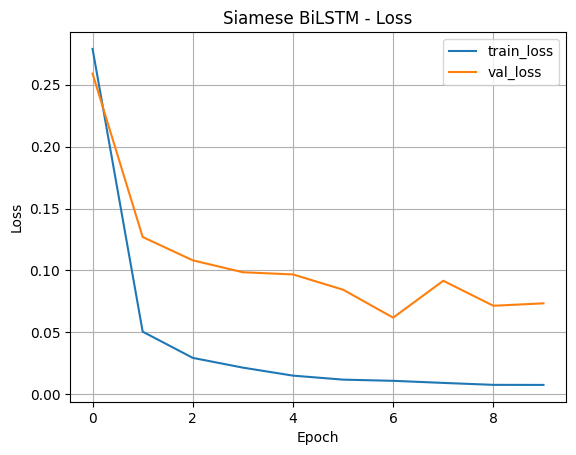

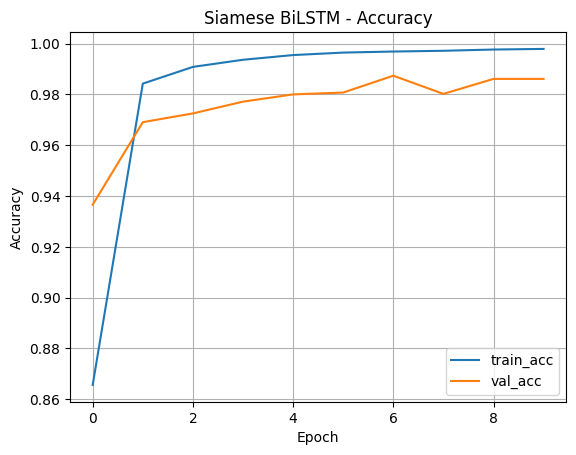

Saved training curves for Siamese BiLSTM

Siamese BiLSTM Performance:
Accuracy : 0.9865
Precision: 0.9738
Recall   : 1.0000
F1-score : 0.9867
ROC-AUC  : 0.9989

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99      7545
           1       0.97      1.00      0.99      7544

    accuracy                           0.99     15089
   macro avg       0.99      0.99      0.99     15089
weighted avg       0.99      0.99      0.99     15089



In [13]:
#Train: Siamese BiLSTM

callbacks_b1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

hist_b1 = model_b1.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=([X1_val, X2_val], y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks_b1,
    verbose=1
)

plot_history(hist_b1, "Siamese BiLSTM")
save_training_curves(hist_b1, "Siamese BiLSTM")

res_b1 = evaluate_model(
    model_b1,
    X1_test,
    X2_test,
    y_test,
    name="Siamese BiLSTM"
)

In [14]:
# Model 2 – Siamese BiLSTM + Attention

class SimpleAttention(layers.Layer):
    def __init__(self, units=64, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.W = layers.Dense(units, activation='tanh')
        self.v = layers.Dense(1)

    def call(self, inputs, mask=None):
        # inputs: (batch, seq, hidden)
        score = self.v(self.W(inputs))  # (batch, seq, 1)
        if mask is not None:
            mask = tf.cast(mask[:, :, None], tf.float32)
            score = score - (1.0 - mask) * 1e9
        weights = tf.nn.softmax(score, axis=1)  # (batch, seq, 1)
        context = tf.reduce_sum(weights * inputs, axis=1)  # (batch, hidden)
        return context

def build_bilstm_att_encoder(name="bilstm_att_encoder"):
    inp = Input(shape=(MAX_LEN,), name=f"{name}_input")
    emb = layers.Embedding(MAX_VOCAB, EMB_DIM, mask_zero=True, name=f"{name}_emb")(inp)
    x = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True),
        name=f"{name}_bilstm"
    )(emb)
    mask = emb._keras_mask
    attn = SimpleAttention(name=f"{name}_attn")(x, mask=mask)
    x = layers.Dense(128, activation='relu', name=f"{name}_dense")(attn)
    x = layers.Dropout(0.2, name=f"{name}_dropout")(x)
    return models.Model(inp, x, name=name)

def build_siamese_bilstm_att():
    encoder = build_bilstm_att_encoder()

    inp1 = Input(shape=(MAX_LEN,), name="clause1_input")
    inp2 = Input(shape=(MAX_LEN,), name="clause2_input")

    enc1 = encoder(inp1)
    enc2 = encoder(inp2)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]), name="abs_diff")([enc1, enc2])
    mult = layers.Multiply(name="elementwise_mult")([enc1, enc2])
    concat = layers.Concatenate(name="concat")([enc1, enc2, diff, mult])

    x = layers.Dense(128, activation='relu', name="top_dense")(concat)
    x = layers.Dropout(0.3, name="top_dropout")(x)
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    model = models.Model(inputs=[inp1, inp2], outputs=out, name="Siamese_BiLSTM_Attention")
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-3),
        metrics=['accuracy']
    )
    return model

model_b2 = build_siamese_bilstm_att()
model_b2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bilstm_att_encoder_attn' (of type SimpleAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Siamese_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ clause1_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clause2_input       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_att_encoder  │ (None, 128)       │  4,152,577 │ clause1_input[0]… │
│ (Functional)        │                   │            │ clause2_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_diff (Lambda)   │ (None, 128)       │          0 │ bilstm_att_encod… │
│                     │                   │            │ bilstm_att_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elementwise_mult    │ (None, 128)       │          0 │ bilstm_att_encod… │
│ (Multiply)          │                   │            │ bilstm_att_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 512)       │          0 │ bilstm_att_encod… │
│ (Concatenate)       │                   │            │ bilstm_att_encod… │
│                     │                   │            │ abs_diff[0][0],   │
│                     │                   │            │ elementwise_mult… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dense (Dense)   │ (None, 128)       │     65,664 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dropout         │ (None, 128)       │          0 │ top_dense[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ top_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,218,370 (16.09 MB)

 Trainable params: 4,218,370 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - accuracy: 0.8016 - loss: 0.3587 - val_accuracy: 0.9638 - val_loss: 0.1522
Epoch 2/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9776 - val_loss: 0.0959
Epoch 3/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9949 - loss: 0.0175 - val_accuracy: 0.9807 - val_loss: 0.0795
Epoch 4/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9963 - loss: 0.0132 - val_accuracy: 0.9830 - val_loss: 0.0779
Epoch 5/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9974 - loss: 0.0097 - val_accuracy: 0.9821 - val_loss: 0.0803
Epoch 6/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9974 - loss: 0.0088 - val_accuracy: 0.9773 - val_loss: 0.1226
Epoch 7/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9866 - val_loss: 0.0747
Epoch 8/15
944/944 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9983 - loss: 0.0055 - 

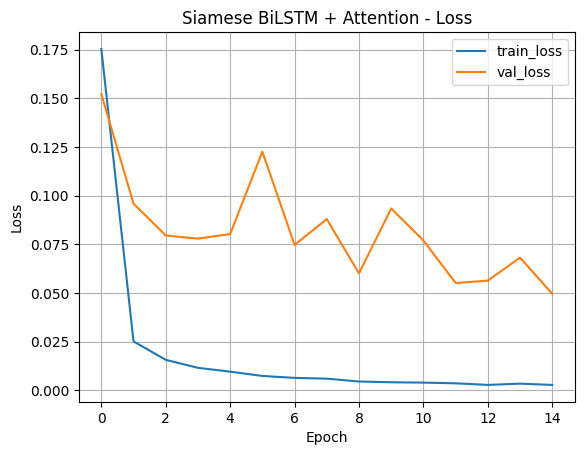

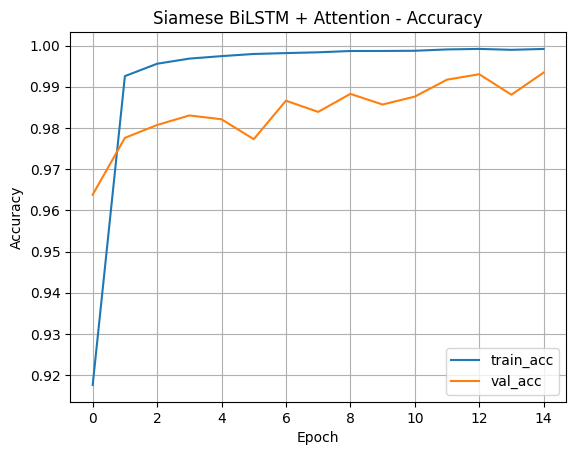

Saved training curves for Siamese BiLSTM + Attention

Siamese BiLSTM + Attention Performance:
Accuracy : 0.9928
Precision: 0.9861
Recall   : 0.9997
F1-score : 0.9929
ROC-AUC  : 0.9990

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      7545
           1       0.99      1.00      0.99      7544

    accuracy                           0.99     15089
   macro avg       0.99      0.99      0.99     15089
weighted avg       0.99      0.99      0.99     15089



In [15]:
 #Train 2 – Siamese BiLSTM + Attention

callbacks_b2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

hist_b2 = model_b2.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=([X1_val, X2_val], y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks_b2,
    verbose=1
)

plot_history(hist_b2, "Siamese BiLSTM + Attention")
save_training_curves(hist_b2, "Siamese BiLSTM + Attention")

res_b2 = evaluate_model(
    model_b2,
    X1_test,
    X2_test,
    y_test,
    name="Siamese BiLSTM + Attention"
)

In [16]:
save_training_curves(hist_b1, "BiLSTM")
save_training_curves(hist_b2, "BiLSTM + Attention")


Saved training curves for BiLSTM
Saved training curves for BiLSTM + Attention


In [17]:
# Results Comparison Table

results_df = pd.DataFrame([res_b1, res_b2])
print(results_df)
results_df.to_csv("model_results.csv", index=False)

                        model       acc      prec       rec        f1  \
0              Siamese BiLSTM  0.986546  0.973796  1.000000  0.986724   
1  Siamese BiLSTM + Attention  0.992842  0.986140  0.999735  0.992891   

        auc  
0  0.998860  
1  0.998971  


In [18]:
#Qualitative Examples (Correct & Incorrect)

def show_examples(model, df, X1, X2, y_true, n=5, name="Model"):
    preds = model.predict([X1, X2], verbose=0).ravel()
    y_pred = (preds >= 0.5).astype(int)

    df = df.reset_index(drop=True)
    correct_idx = np.where(y_pred == y_true)[0]
    wrong_idx = np.where(y_pred != y_true)[0]

    print(f"\n{name} - Correct predictions (first {n}):")
    for i in correct_idx[:n]:
        print(f"\nTrue={y_true[i]}, Pred={y_pred[i]}, Score={preds[i]:.3f}")
        print("Clause1:", df.loc[i, 'clause1'][:250])
        print("Clause2:", df.loc[i, 'clause2'][:250])

    print(f"\n{name} - Incorrect predictions (first {n}):")
    for i in wrong_idx[:n]:
        print(f"\nTrue={y_true[i]}, Pred={y_pred[i]}, Score={preds[i]:.3f}")
        print("Clause1:", df.loc[i, 'clause1'][:250])
        print("Clause2:", df.loc[i, 'clause2'][:250])

show_examples(model_b1, test_df, X1_test, X2_test, y_test, n=5, name="Siamese BiLSTM")
show_examples(model_b2, test_df, X1_test, X2_test, y_test, n=5, name="Siamese BiLSTM + Attention")


Siamese BiLSTM - Correct predictions (first 5):

True=1, Pred=1, Score=1.000
Clause1: additional agreements. this agreement, together with the service agreements (as defined below), form a legally binding contract between you and dell in relation to your purchase and use of software, and dell's performance of services. in the event of
Clause2: additional agreements. section 6.1 preparation of proxy statement.............................42 section 6.2 stockholders meeting; company recommendation...............43 section 6.3 access to information; confidentiality.....................43 secti

True=1, Pred=1, Score=1.000
Clause1: modification. this agreement may be modified or amended only by a writing signed by each of the parties hereto.
Clause2: modification. this agreement may be modified only by a written agreement signed by both parties. any such written modification may only be signed by chief executive officer of the company.

True=1, Pred=1, Score=1.000
Clause1: whereas the sell